# Gradient Pattern Analysis (GPA) Applied to Simulated Galaxies

## Authors

**Carlos Eduardo Falandes**

M.Sc. Candidate in Applied Computing
National Institute for Space Research (INPE), Brazil

**Mariana Rubet**

National Observatory (ON), Brazil

**Master's Dissertation:**

*Gradient Pattern Analysis (GPA): Two New Applications for Pattern Characterization in Physics of Extreme Events and Extragalactic Astronomy*

**Contact:** [carloseduardofalandes@gmail.com](mailto:carloseduardofalandes@gmail.com)

This notebook is part of the GPA Python implementation developed during Falandes master's research, in collaboration with Rubet.

---

## Overview

This notebook applies **Gradient Pattern Analysis (GPA)** to simulated galaxy images to investigate its ability to characterize different galaxy morphologies and assess the effects of noise.

Four simulated galaxies are analyzed:

* Elliptical galaxy.
* Elliptical galaxy with noise.
* Spiral galaxy.
* Spiral galaxy with noise.

The analysis combines astronomical source detection and masking using **Source Extractor (SEP)** with the GPA method.

For each image, the galaxy is detected, its center is estimated, and the GPA descriptors are calculated.

## Dataset

The validation dataset consists of four simulated galaxy images:

| Image                         | Morphology | Noise |
| ----------------------------- | ---------- | ----- |
| `elliptical_galaxy.tif`       | Elliptical | No    |
| `elliptical_galaxy_noise.tif` | Elliptical | Yes   |
| `spiral_galaxy.tif`           | Spiral     | No    |
| `spiral_galaxy_noise.tif`     | Spiral     | Yes   |

The images were generated synthetically to provide controlled examples with known morphological properties.

## Analysis

The notebook follows these steps:

1. Load the simulated galaxy images.
2. Estimate the background and detect sources using SEP.
3. Generate source masks and estimate the galaxy center.
4. Apply Gradient Pattern Analysis.
5. Calculate the GPA descriptors.
6. Visualize the gradient and asymmetric gradient fields.
7. Compare the results across galaxy morphologies and noise conditions.


## Imports

The following packages are used for image processing, astronomical source extraction, visualization, and GPA computation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.path import Path as MplPath

# plt.rcParams["figure.dpi"] = 600
# plt.rcParams["savefig.dpi"] = 600
from astropy.io import fits

from gpa.gpa import GPA
import sep

## Configuration

The simulated galaxy images are stored in the validation data directory.

The paths below should be adjusted according to the location of the repository.

In [2]:
DATA_DIR = Path("../data")

images = {
    "Elliptical": DATA_DIR / "elliptical_galaxy.fit",
    "Elliptical + Noise": DATA_DIR / "elliptical_galaxy_noise.fit",
    "Spiral": DATA_DIR / "spiral_galaxy.fit",
    "Spiral + Noise": DATA_DIR / "spiral_galaxy_noise.fit",
}

images

{'Elliptical': PosixPath('../data/elliptical_galaxy.fit'),
 'Elliptical + Noise': PosixPath('../data/elliptical_galaxy_noise.fit'),
 'Spiral': PosixPath('../data/spiral_galaxy.fit'),
 'Spiral + Noise': PosixPath('../data/spiral_galaxy_noise.fit')}

In [3]:
DATA_DIR = Path("...")

## Loading the Galaxy Images

The TIFF images are loaded as NumPy arrays.

The numerical image representation is used for both source extraction with SEP and the subsequent GPA analysis.

In [4]:
galaxy_data = {}

for name, path in images.items():

    with fits.open(path) as hdul:
        image = hdul[0].data.astype(np.float32)

    galaxy_data[name] = image

    print(f"{name}:")
    print(f"  Shape: {image.shape}")
    print(f"  dtype: {image.dtype}")
    print(f"  min:   {np.nanmin(image):.4f}")
    print(f"  max:   {np.nanmax(image):.4f}")
    print(f"  mean:  {np.nanmean(image):.4f}")
    print()

Elliptical:
  Shape: (101, 101)
  dtype: float32
  min:   27.4578
  max:   6137.8745
  mean:  974.3214

Elliptical + Noise:
  Shape: (101, 101)
  dtype: float32
  min:   26.0000
  max:   6198.0000
  mean:  974.1525

Spiral:
  Shape: (101, 101)
  dtype: float32
  min:   112.4124
  max:   3821.9041
  mean:  969.2377

Spiral + Noise:
  Shape: (101, 101)
  dtype: float32
  min:   108.0000
  max:   3852.0000
  mean:  969.1158



## Galaxy Images

Before applying the source extraction and GPA procedures, the four simulated galaxies are visually inspected.

This allows the morphological differences between elliptical and spiral galaxies, as well as the effect of the added noise, to be verified.

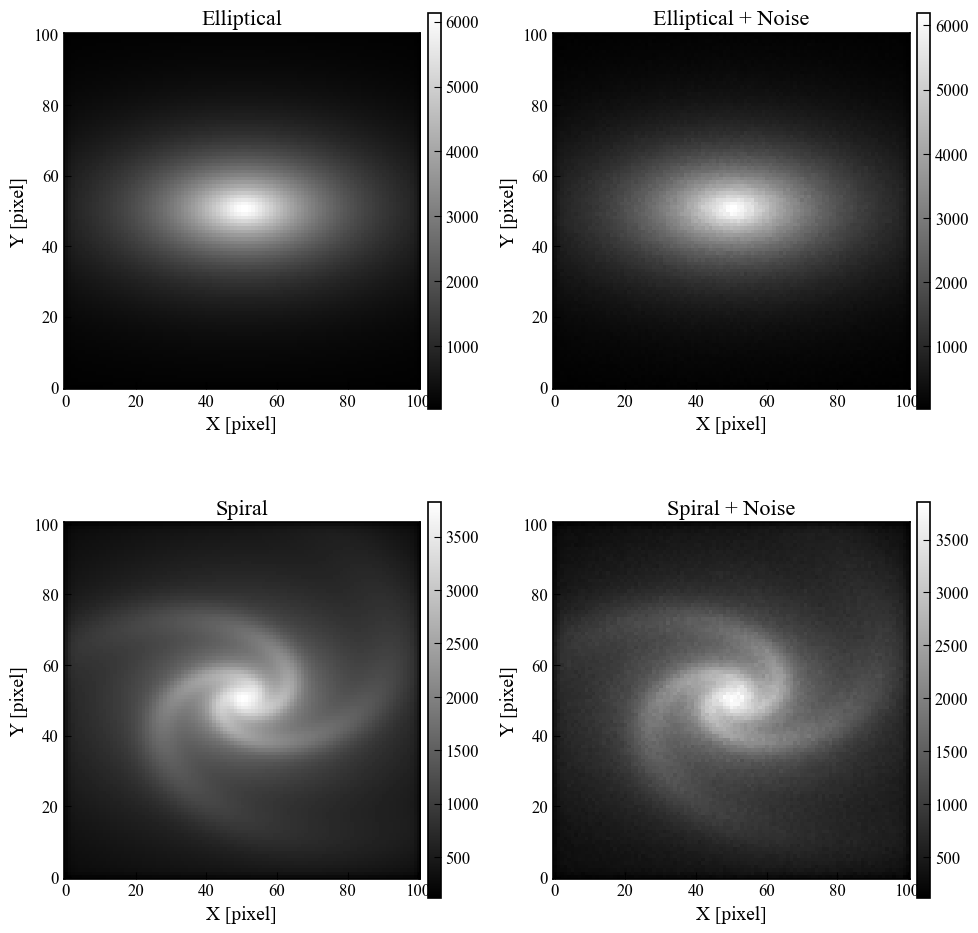

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, (name, image) in zip(axes.flat, galaxy_data.items()):
    im = ax.imshow(image, origin="lower", cmap="gray")
    ax.set_title(name)
    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")
    cbar = plt.colorbar(
        im,
        ax=ax,
        fraction=0.035,
        pad=0.02,
        aspect=30
    )

plt.tight_layout()
plt.show()

## Contour Plot

The contour lines represent the spatial distribution of the object's flux.

In [6]:
image.shape[0], image.shape[1]

(101, 101)

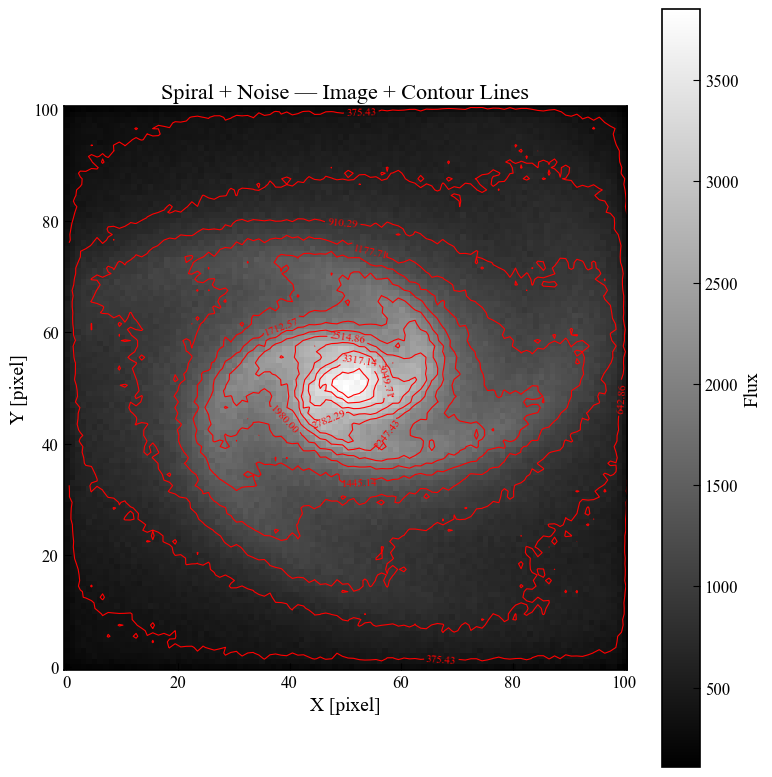

In [7]:
name = "Spiral + Noise"

image = galaxy_data[name]

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    image,
    origin="lower",
    cmap="gray"
)

levels = np.linspace(
    np.nanmin(image),
    np.nanmax(image),
    15
)

contours = ax.contour(
    image,
    levels=levels,
    colors="red",
    linewidths=0.8,
    origin="lower"
)

ax.clabel(
    contours,
    inline=True,
    fontsize=8,
    fmt="%.2f"
)

ax.set_title(
    f"{name} — Image + Contour Lines"
)

ax.set_xlabel("X [pixel]")
ax.set_ylabel("Y [pixel]")

plt.colorbar(
    im,
    ax=ax,
    label="Flux"
)

plt.tight_layout()
plt.show()

In [8]:
def analyze_galaxy(
    image,
    magnitude_threshold=0.01,
    magnitude_tolerance=0.15,
    angle_tolerance=30,
    radial_distance_tolerance=0.5,
    symmetric_position_tolerance=0.5,
):

    # GPA
    gpa_object = GPA(image)

    results = gpa_object.evaluate(
        magnitude_threshold=magnitude_threshold,
        magnitude_tolerance=magnitude_tolerance,
        angle_tolerance=angle_tolerance,
        radial_distance_tolerance=radial_distance_tolerance,
        symmetric_position_tolerance=symmetric_position_tolerance,
    )

    return {
        "gpa": gpa_object,
        "results": results,
    }

## GPA Analysis

The same analysis pipeline is now applied to all four simulated galaxies.

The GPA parameters are kept fixed across all experiments to ensure that the resulting measurements can be directly compared.

In [9]:
results = {}

for name, image in galaxy_data.items():

    print(f"Analyzing {name}...")

    results[name] = analyze_galaxy(image)

    print(f"  GPA results: {results[name]['results']}")
    print()

Analyzing Elliptical...
  GPA results: {'G1': 1.8085106382978724, 'G2': np.float32(0.007824058), 'G3': None, 'G4': None}

Analyzing Elliptical + Noise...
  GPA results: {'G1': 1.9964367523542885, 'G2': np.float32(0.7674749), 'G3': None, 'G4': None}

Analyzing Spiral...
  GPA results: {'G1': 1.99234360410831, 'G2': np.float32(1.0381904), 'G3': None, 'G4': None}

Analyzing Spiral + Noise...


/Users/carloseduardofalandes/Documents/master/gpa-temp/src/gpa/gpa.py:284: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


  GPA results: {'G1': 1.9983700081499594, 'G2': np.float32(1.4379103), 'G3': None, 'G4': None}



## GPA Gradient Fields

The GPA gradient field is visualized for each galaxy.

The gradient field represents the local spatial variation of the image intensity.

The organization of these vectors provides the basis for the subsequent GPA analysis.

Elliptical


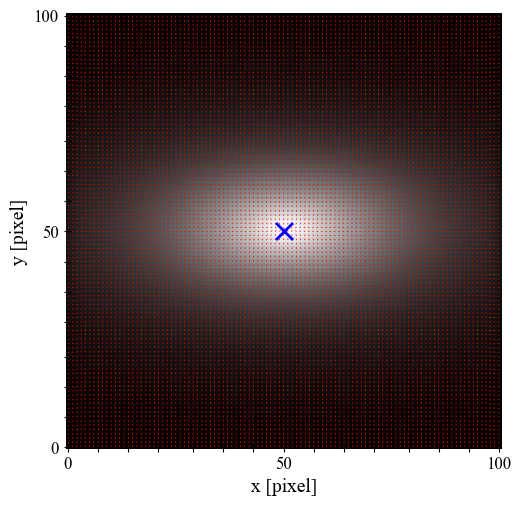

Elliptical + Noise


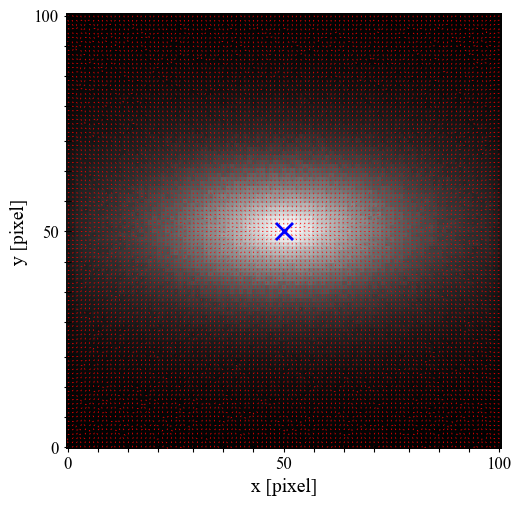

Spiral


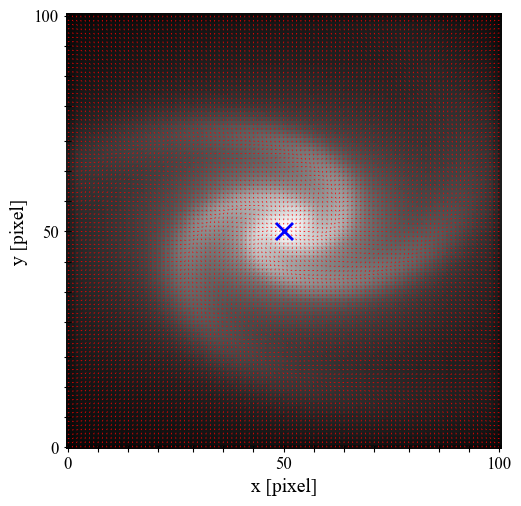

Spiral + Noise


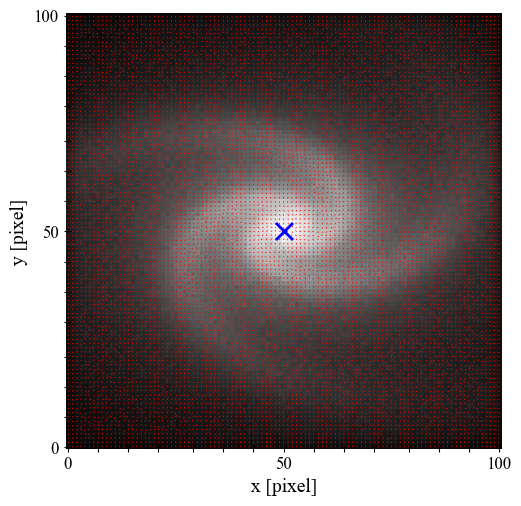

In [10]:
for name, data in results.items():

    print(name)

    data["gpa"].plot_gradient_field()

## Asymmetric Gradient Fields

The asymmetric gradient field is obtained after removing the radially symmetric gradient vectors according to the GPA criteria.

This representation is particularly useful for investigating the morphological differences between elliptical and spiral galaxies.

Elliptical


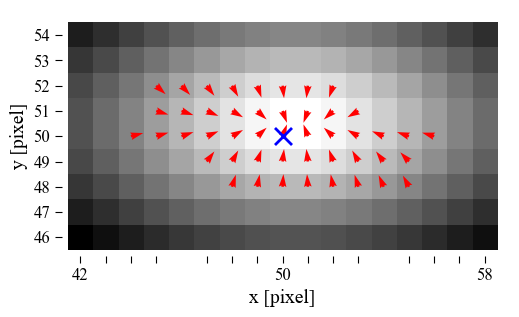

Elliptical + Noise


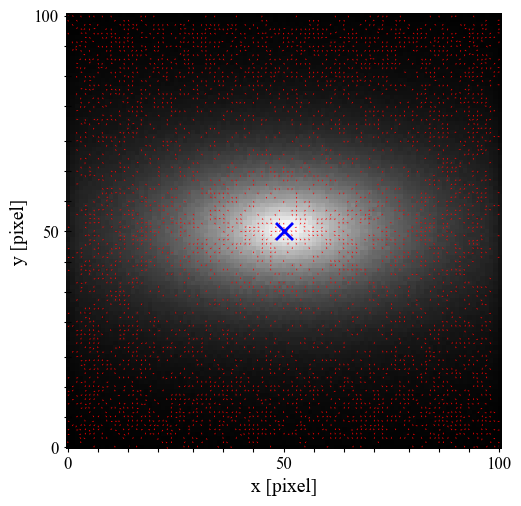

Spiral


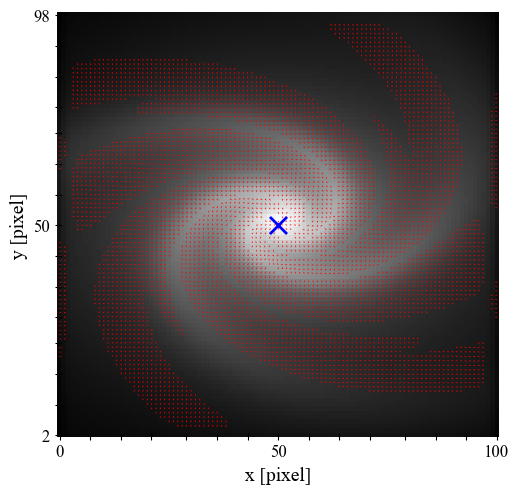

Spiral + Noise


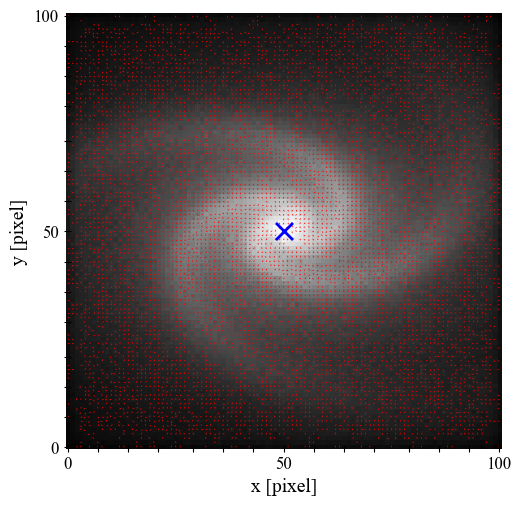

In [11]:
for name, data in results.items():

    print(name)

    data["gpa"].plot_asymmetric_gradient_field()

In [12]:
import pandas as pd

gpa_table = pd.DataFrame.from_dict(
    {
        name: data["results"]
        for name, data in results.items()
    },
    orient="index",
)

gpa_table

,G1,G2,G3,G4
Elliptical,1.808511,0.007824,None,None
Elliptical + Noise,1.996437,0.767475,None,None
Spiral,1.992344,1.038190,None,None
Spiral + Noise,1.998370,1.437910,None,None
